## Environment Setup

This section imports all required libraries used for data processing, visualization, machine learning model development, and explainable AI techniques. Setting up the environment at the beginning ensures that all dependencies are available before executing the analysis.

In [1]:
# Install missing libraries
!pip install lime

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Explainable AI
import shap
from lime.lime_tabular import LimeTabularExplainer

# Plot settings
sns.set(style="whitegrid")

print("Environment setup completed.")

Environment setup completed.


## Mount Google Drive

The dataset used for this study is stored in Google Drive. Mounting Google Drive allows the notebook to access the dataset directly for analysis and model development.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset

In [3]:
data_path = "/content/drive/MyDrive/Dataset/cardiovascular_risk_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset successfully loaded.")
print("Dataset shape:", df.shape)

df.head()

Dataset successfully loaded.
Dataset shape: (5500, 17)


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


**Missing Value Analysis**

In [4]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values in dataset:", missing_values.sum())

Missing values per column:
Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Total missing values in dataset: 0


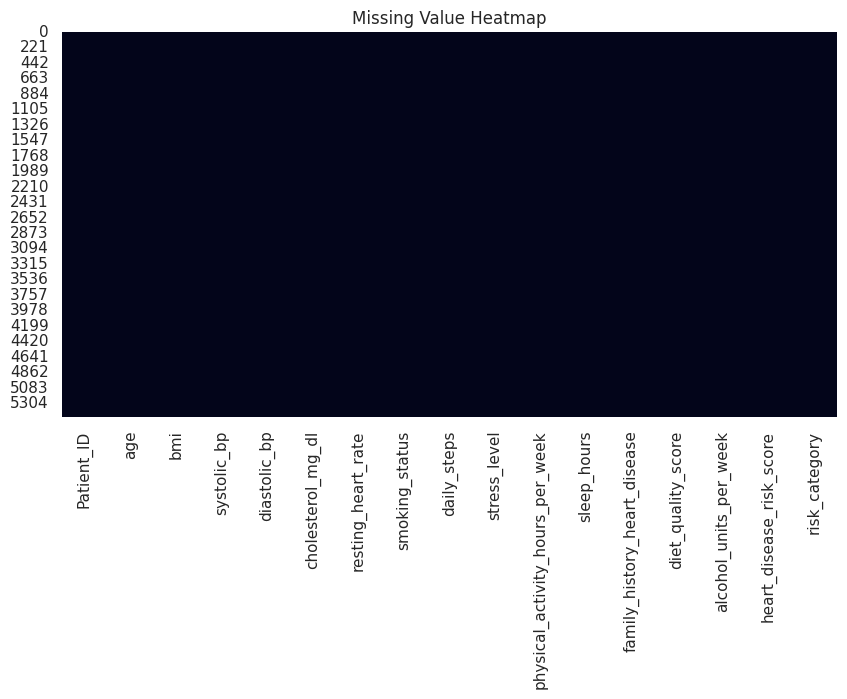

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

**Duplicate Record Detection**

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**Statistical Summary**

In [7]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


**Target Variable Distribution**

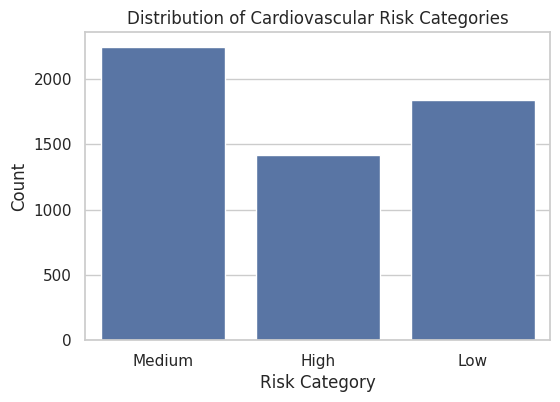

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="risk_category", data=df)

plt.title("Distribution of Cardiovascular Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

**Feature Correlation Analysis**

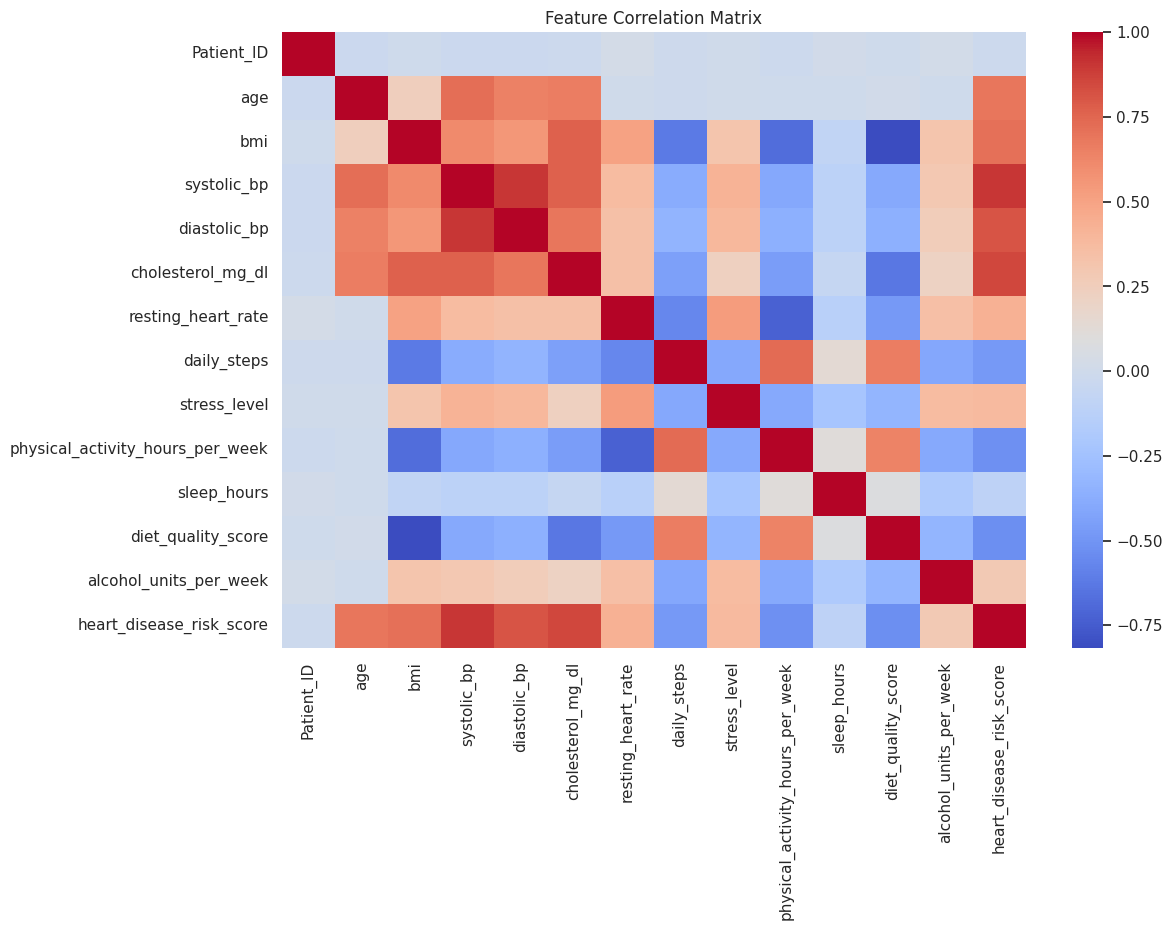

In [9]:
plt.figure(figsize=(12,8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Feature Correlation Matrix")

plt.show()

The correlation heatmap visualizes the relationships between numerical variables in the dataset. At this stage, all original dataset features are included, including Patient_ID and heart_disease_risk_score. While these variables appear in the visualization, they are not suitable for predictive modeling. Patient_ID is a unique identifier and does not contain meaningful predictive information, whereas heart_disease_risk_score may introduce data leakage because it is used to derive the target variable (risk_category). These features will therefore be removed in the preprocessing stage.

## Dataset Inspection

In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nPreview of Dataset:")
df.head()

Dataset Shape: (5500, 17)

Column Names:
Index(['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp',
       'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status',
       'daily_steps', 'stress_level', 'physical_activity_hours_per_week',
       'sleep_hours', 'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'heart_disease_risk_score', 'risk_category'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5  

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


## Remove Irrelevant / Leakage Features


Two columns are removed before model development:

• **Patient_ID** – This column is a unique identifier and does not contain predictive information. Including it in the model may introduce noise.

• **heart_disease_risk_score** – This variable is used to derive the target variable (`risk_category`). Including it would introduce **data leakage**, allowing the model to indirectly access the target label and artificially inflate prediction accuracy.

To ensure fair and reliable model training, both columns are removed from the dataset.

In [11]:
columns_to_drop = []

if "Patient_ID" in df.columns:
    columns_to_drop.append("Patient_ID")

if "heart_disease_risk_score" in df.columns:
    columns_to_drop.append("heart_disease_risk_score")

df = df.drop(columns=columns_to_drop)

print("Removed Columns:", columns_to_drop)
print("Updated Dataset Shape:", df.shape)
print("\nRemaining Columns:")
print(df.columns)

Removed Columns: ['Patient_ID', 'heart_disease_risk_score']
Updated Dataset Shape: (5500, 15)

Remaining Columns:
Index(['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
       'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level',
       'physical_activity_hours_per_week', 'sleep_hours',
       'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'risk_category'],
      dtype='object')


## Encode Categorical Variables


Machine learning algorithms require numerical inputs. Therefore, categorical variables are converted into numerical representations.

The following variables are encoded:

• **smoking_status**
• **family_history_heart_disease**

Ordinal encoding is used to represent categorical levels as integers.

In [12]:
df["smoking_status"] = df["smoking_status"].map({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

df["family_history_heart_disease"] = df["family_history_heart_disease"].map({
    "No": 0,
    "Yes": 1
})

print("Categorical encoding completed.")

df.head()

Categorical encoding completed.


,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,risk_category
0,62,25.0,142,93,247,72,0,11565,3,5.6,8.2,0,7,0.7,Medium
1,54,29.7,158,101,254,74,2,4036,8,0.5,6.7,0,5,4.5,High
2,46,36.2,170,113,276,80,2,3043,9,0.4,4.0,0,1,20.8,High
3,48,30.4,153,98,230,73,1,5604,5,0.6,8.0,0,4,8.5,Medium
4,46,25.3,139,87,206,69,2,7464,1,2.0,6.1,0,5,3.6,Medium


### Target Variable Encoding

The target variable `risk_category` is categorical and therefore must be converted into numerical labels before training machine learning models.

The following mapping is used:

Low → 0  
Medium → 1  
High → 2

In [13]:
# Encode target variable
df["risk_category"] = df["risk_category"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

print("Target encoding completed.")

print("\nTarget Distribution After Encoding:")
print(df["risk_category"].value_counts())

Target encoding completed.

Target Distribution After Encoding:
risk_category
1    2244
0    1838
2    1418
Name: count, dtype: int64


**Feature and Target Separation**

In [14]:
X = df.drop("risk_category", axis=1)
y = df["risk_category"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (5500, 14)
Target vector shape: (5500,)


## Train-Test Split

The dataset is divided into training and testing subsets.

• **Training Set (80%)** – used to train machine learning models  
• **Testing Set (20%)** – used to evaluate model performance

Stratified sampling is applied to preserve the original distribution of the target classes.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (4400, 14)
Testing set shape: (1100, 14)


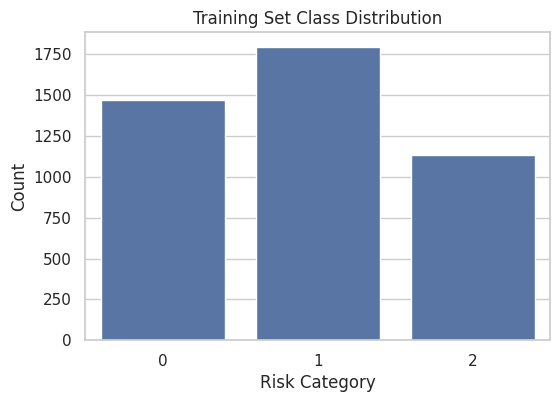

In [16]:
# Visualize class distribution after split

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Training Set Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()

## Feature Scaling

Feature scaling is applied to normalize numerical features. Standardization transforms the data so that each feature has a mean of 0 and a standard deviation of 1.

This step is particularly important for models such as Logistic Regression and Artificial Neural Networks.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Logistic Regression Baseline Model

Logistic Regression is used as the baseline model for this study.
Although originally designed for binary classification, it can also be applied to multi-class classification problems using strategies such as the One-vs-Rest approach.

Using a baseline model helps establish a reference performance level against which more advanced models can be compared.

In [19]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)

**Evaluation Function**

In [20]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name} Performance Metrics")
    print("----------------------------------")

    print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")

    return accuracy, precision, recall, f1

In [21]:
log_accuracy, log_precision, log_recall, log_f1 = evaluate_model(
    y_test,
    y_pred_log,
    y_prob_log,
    "Logistic Regression"
)


Logistic Regression Performance Metrics
----------------------------------
Accuracy  : 0.9509 (95.09%)
Precision : 0.9511 (95.11%)
Recall    : 0.9509 (95.09%)
F1 Score  : 0.9510 (95.10%)


### Confusion Matrix - Logistic Regression

The confusion matrix visualizes the classification performance by comparing predicted labels against actual labels.

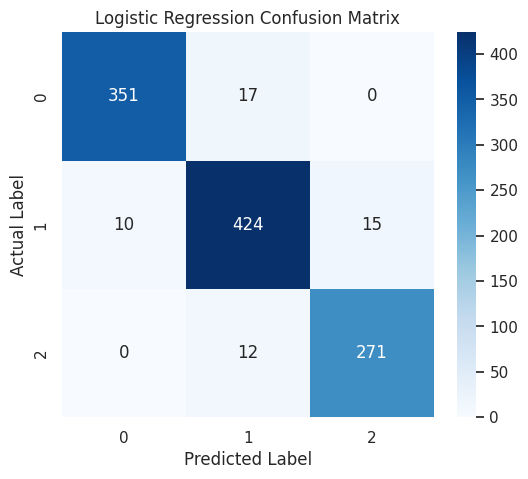

In [22]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### ROC Curve - Logistic Regression

Receiver Operating Characteristic (ROC) curves illustrate the diagnostic ability of the classification model across different threshold values.

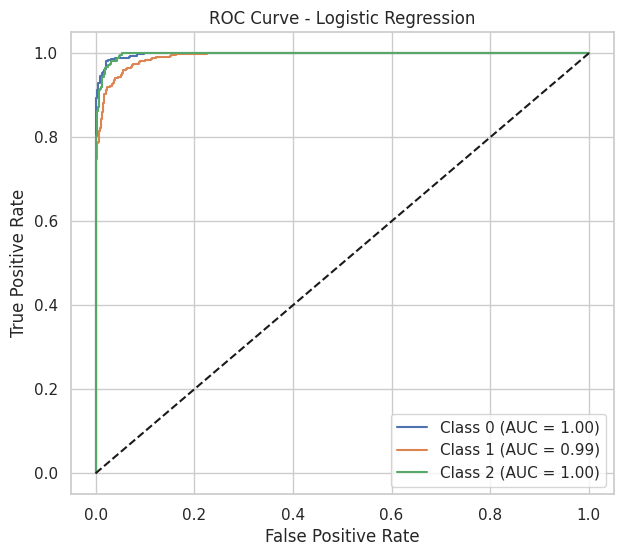

In [23]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_log[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob_log[:, i])

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {auc_score:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

**Store Logistic Regression Results**

In [68]:
model_results = pd.DataFrame(columns=[
    "Model",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
])

model_results.loc[len(model_results)] = [
    "Logistic Regression",
    log_accuracy * 100,
    log_precision * 100,
    log_recall * 100,
    log_f1 * 100
]

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.090909,95.110864,95.090909,95.09648


## Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Each tree in the forest is trained on a different subset of the data using bootstrap sampling, and predictions are aggregated across trees.

Random Forest is particularly effective for tabular datasets because it can capture complex nonlinear relationships between variables.

Another advantage of Random Forest is that it provides **feature importance scores**, which help identify the most influential predictors in the dataset.

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)

In [26]:
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf,
    "Random Forest"
)


Random Forest Performance Metrics
----------------------------------
Accuracy  : 0.9018 (90.18%)
Precision : 0.9038 (90.38%)
Recall    : 0.9018 (90.18%)
F1 Score  : 0.9022 (90.22%)


**Confusion Matrix - Random Forest**

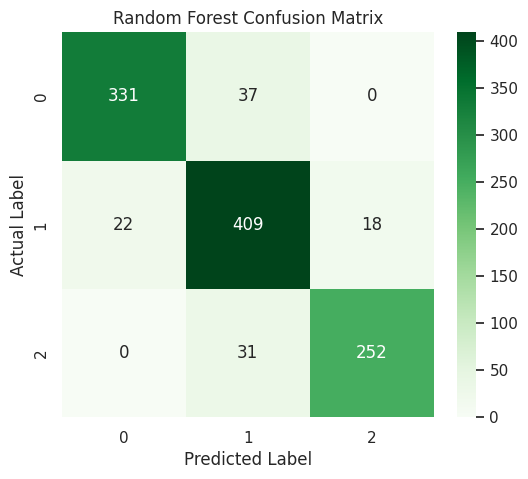

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**ROC Curve - Random Forest**

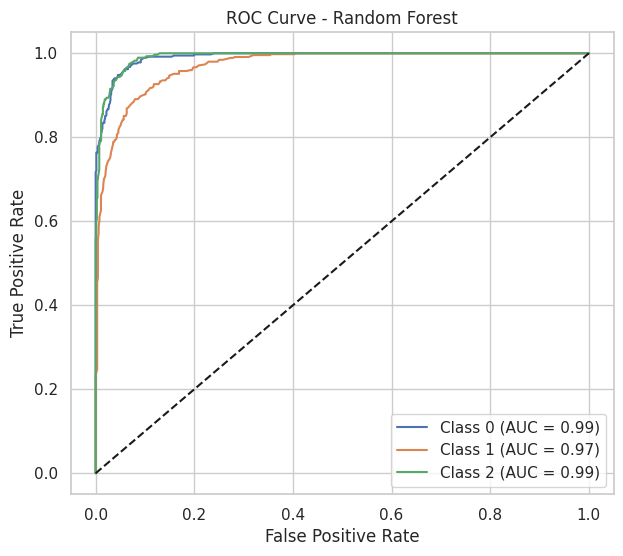

In [28]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob_rf[:, i])

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Feature Importance Analysis

Random Forest calculates feature importance based on how much each feature reduces impurity across the decision trees.

This allows us to identify which variables contribute most strongly to cardiovascular risk prediction.

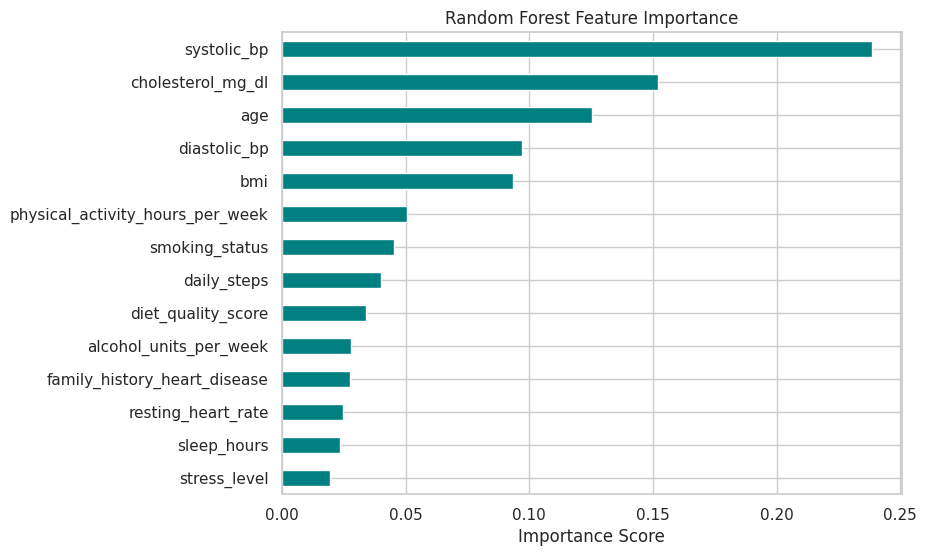

In [29]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

feature_importance.plot(
    kind="barh",
    color="teal"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()

**Store Random Forest Results**

In [30]:
model_results.loc[len(model_results)] = [
    "Random Forest",
    rf_accuracy * 100,
    rf_precision * 100,
    rf_recall * 100,
    rf_f1 * 100
]

model_results = model_results.round(2)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22


## Gradient Boosting Model

Gradient Boosting is an ensemble learning technique that builds models sequentially.
Each new model attempts to correct the prediction errors made by the previous model.

Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees in sequence, gradually improving the model's performance.

Gradient Boosting is widely used in predictive analytics because it can capture complex nonlinear relationships and interactions between features.

In [31]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)

**Evaluate Gradient Boosting**

In [32]:
gb_accuracy, gb_precision, gb_recall, gb_f1 = evaluate_model(
    y_test,
    y_pred_gb,
    y_prob_gb,
    "Gradient Boosting"
)


Gradient Boosting Performance Metrics
----------------------------------
Accuracy  : 0.9145 (91.45%)
Precision : 0.9151 (91.51%)
Recall    : 0.9145 (91.45%)
F1 Score  : 0.9147 (91.47%)


**Confusion Matrix — Gradient Boosting**

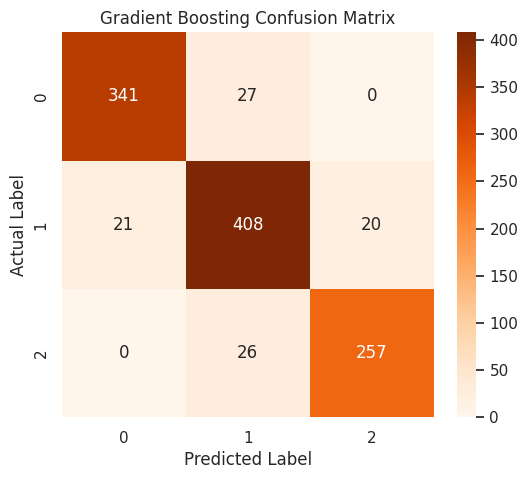

In [33]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**ROC Curve — Gradient Boosting**

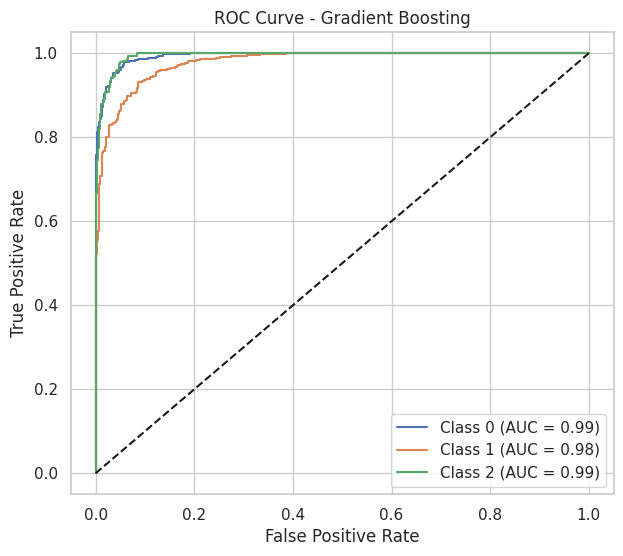

In [34]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob_gb[:, i])

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Feature Importance Analysis

Gradient Boosting provides feature importance scores based on how frequently and effectively each feature is used for decision splits during model training.

This analysis helps identify the variables that contribute most significantly to cardiovascular risk prediction.

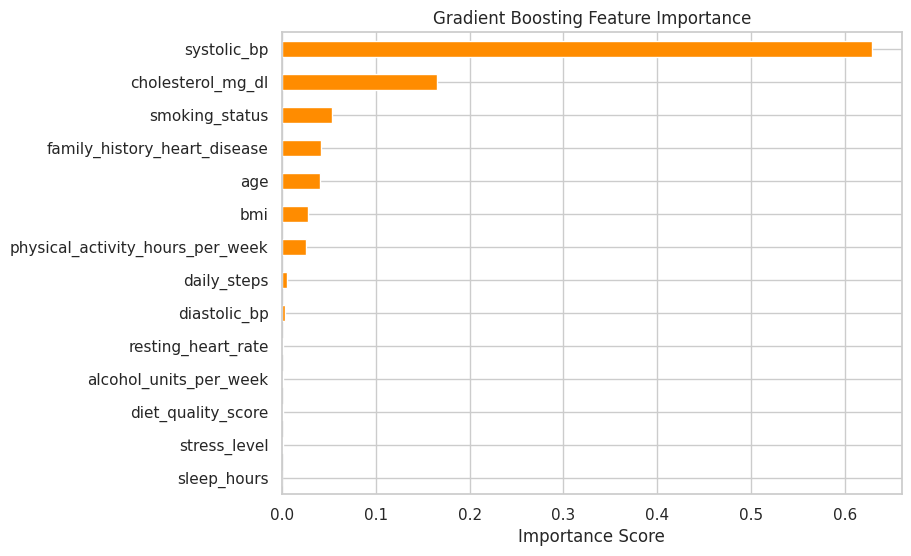

In [35]:
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

gb_importance.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Score")

plt.show()

**Store Gradient Boosting Results**

In [36]:
model_results.loc[len(model_results)] = [
    "Gradient Boosting",
    gb_accuracy * 100,
    gb_precision * 100,
    gb_recall * 100,
    gb_f1 * 100
]

model_results = model_results.round(2)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22
2,Gradient Boosting,91.45,91.51,91.45,91.47


## XGBoost Model

Extreme Gradient Boosting (XGBoost) is an advanced implementation of gradient boosting designed for efficiency and high predictive performance.

XGBoost improves upon traditional boosting techniques by introducing regularization, parallel processing, and optimized tree learning algorithms.

Because of its ability to handle complex nonlinear relationships and interactions between variables, XGBoost has become one of the most widely used algorithms in machine learning competitions and real-world predictive analytics tasks.

In this section, an XGBoost classifier is trained and evaluated to determine whether it improves prediction performance compared to the previous models.

In [37]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

**Evaluate XGBoost Model**

In [38]:
xgb_accuracy, xgb_precision, xgb_recall, xgb_f1 = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb,
    "XGBoost"
)


XGBoost Performance Metrics
----------------------------------
Accuracy  : 0.9255 (92.55%)
Precision : 0.9258 (92.58%)
Recall    : 0.9255 (92.55%)
F1 Score  : 0.9256 (92.56%)


**Confusion Matrix — XGBoost**

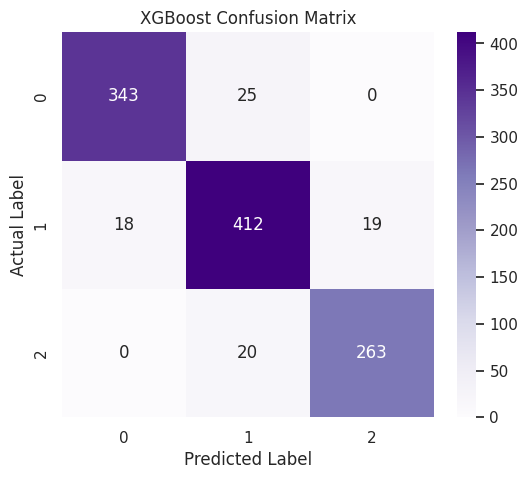

In [39]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**ROC Curve — XGBoost**

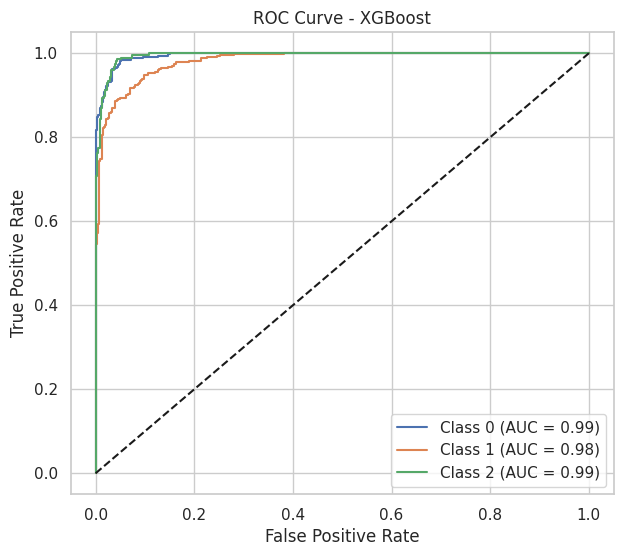

In [40]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob_xgb[:, i])

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Feature Importance Analysis

XGBoost calculates feature importance based on how frequently and effectively each feature contributes to tree splits during model training.

Analyzing feature importance helps identify the most influential predictors of cardiovascular risk.

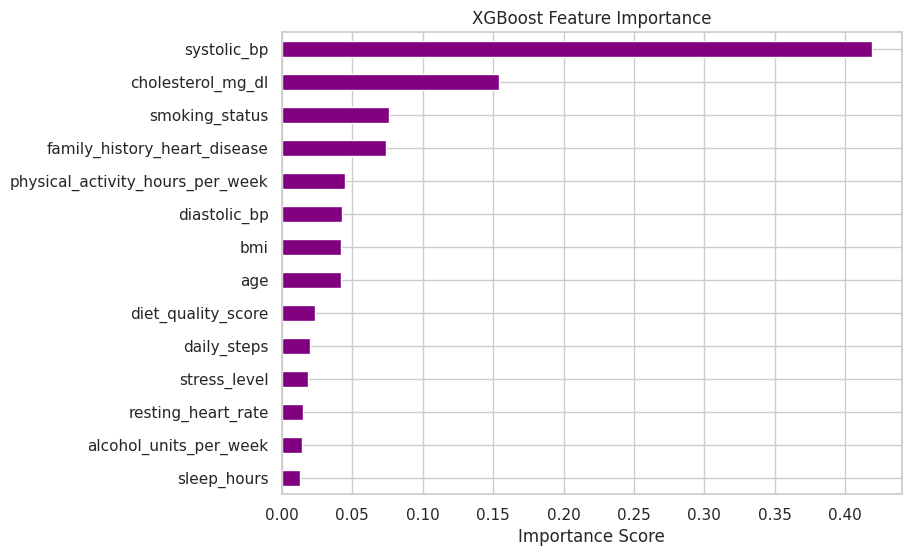

In [41]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

xgb_importance.plot(
    kind="barh",
    color="purple"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")

plt.show()

**Store XGBoost Results**

In [42]:
model_results.loc[len(model_results)] = [
    "XGBoost",
    xgb_accuracy * 100,
    xgb_precision * 100,
    xgb_recall * 100,
    xgb_f1 * 100
]

model_results = model_results.round(2)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22
2,Gradient Boosting,91.45,91.51,91.45,91.47
3,XGBoost,92.55,92.58,92.55,92.56


## Artificial Neural Network (ANN)

Artificial Neural Networks are inspired by biological neural systems and are capable of learning complex nonlinear relationships between variables.

In this study, a feedforward neural network is implemented using TensorFlow and Keras. The network consists of multiple dense layers and uses the ReLU activation function to introduce non-linearity.

Because neural networks are sensitive to feature magnitude, the **scaled feature dataset** is used for training.

In [43]:
# Prepare Data for ANN

from tensorflow.keras.utils import to_categorical

y_train_ann = to_categorical(y_train)
y_test_ann = to_categorical(y_test)

print("ANN target encoding completed")

ANN target encoding completed


### Neural Network Architecture
**Build Neural Network Architecture**

The Artificial Neural Network implemented in this study follows a feedforward architecture designed for multi-class classification of cardiovascular risk.

The architecture consists of the following layers:

• **Input Layer** – The input layer receives the scaled feature vector representing patient clinical and lifestyle characteristics.

• **Hidden Layer 1 (64 neurons)** – A dense fully connected layer using the **ReLU activation function** to capture nonlinear relationships between features. A **Dropout layer (0.3)** is applied to reduce overfitting by randomly deactivating neurons during training.

• **Hidden Layer 2 (32 neurons)** – A second dense layer further refines learned feature representations. Another **Dropout layer (0.3)** is applied to improve generalization.

• **Hidden Layer 3 (16 neurons)** – This layer learns higher-level interactions between the predictors before passing information to the output layer.

• **Output Layer (3 neurons)** – The output layer uses the **Softmax activation function** to generate probability distributions across the three cardiovascular risk categories:

  - Low Risk  
  - Medium Risk  
  - High Risk  

The network is trained using the **Adam optimizer** and **categorical cross-entropy loss function**, which are well-suited for multi-class classification problems.

To improve model stability and prevent overfitting, the network also uses **dropout regularization** and is trained on standardized feature values.

In [44]:
ann_model = Sequential()

ann_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann_model.add(Dropout(0.3))

ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.3))

ann_model.add(Dense(16, activation='relu'))

ann_model.add(Dense(3, activation='softmax'))

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,619 (14.14 KB)

 Trainable params: 3,619 (14.14 KB)

 Non-trainable params: 0 (0.00 B)

**Train Neural Network**

In [45]:
history = ann_model.fit(
    X_train_scaled,
    y_train_ann,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5532 - loss: 0.8929 - val_accuracy: 0.8182 - val_loss: 0.4351
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8038 - loss: 0.4513 - val_accuracy: 0.8614 - val_loss: 0.2957
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8562 - loss: 0.3386 - val_accuracy: 0.8807 - val_loss: 0.2569
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8562 - loss: 0.3164 - val_accuracy: 0.8977 - val_loss: 0.2347
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8679 - loss: 0.2976 - val_accuracy: 0.9114 - val_loss: 0.2226
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8909 - loss: 0.2705 - val_accuracy: 0.9068 - val_loss: 0.2146
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8964 - loss: 0.2480 - val_accuracy: 0.9216 - val_loss: 0.1974
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8943 - loss: 0.2572 - val_acc

**Plot Training Performance**

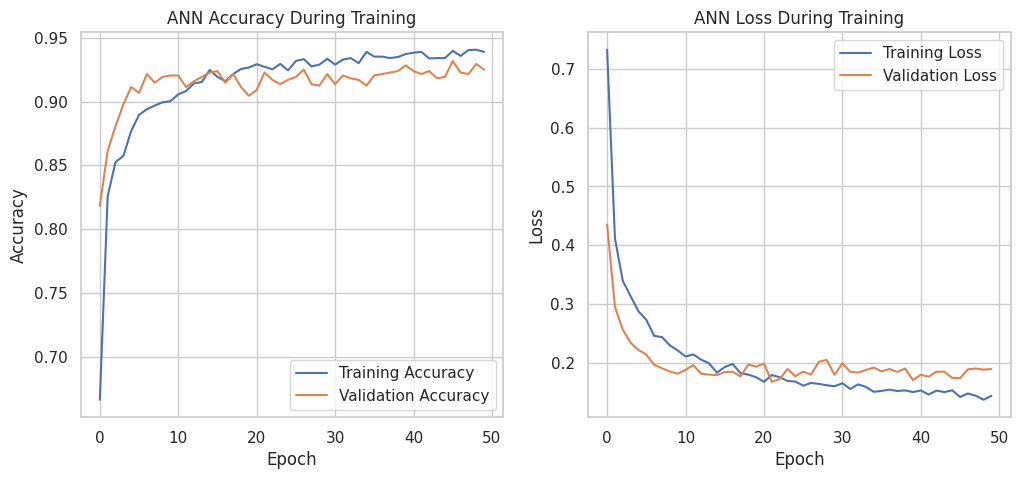

In [46]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [47]:
# ANN Predictions

y_prob_ann = ann_model.predict(X_test_scaled)

y_pred_ann = np.argmax(y_prob_ann, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


**Evaluate ANN Model**

In [48]:
ann_accuracy, ann_precision, ann_recall, ann_f1 = evaluate_model(
    y_test,
    y_pred_ann,
    y_prob_ann,
    "Artificial Neural Network"
)


Artificial Neural Network Performance Metrics
----------------------------------
Accuracy  : 0.9427 (94.27%)
Precision : 0.9437 (94.37%)
Recall    : 0.9427 (94.27%)
F1 Score  : 0.9427 (94.27%)


**Confusion Matrix — ANN**

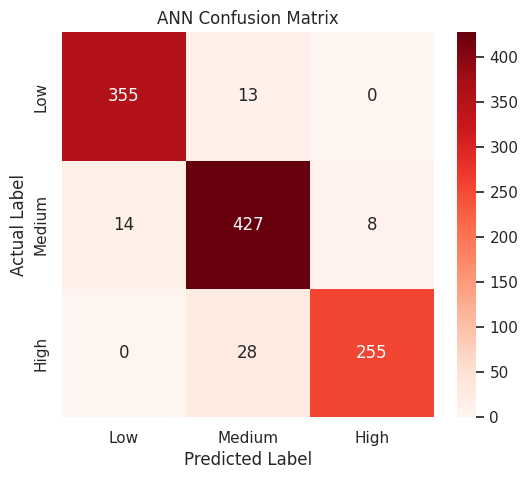

In [49]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_ann,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**Store ANN Results**

In [50]:
model_results.loc[len(model_results)] = [
    "Artificial Neural Network",
    ann_accuracy * 100,
    ann_precision * 100,
    ann_recall * 100,
    ann_f1 * 100
]

model_results = model_results.round(2)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22
2,Gradient Boosting,91.45,91.51,91.45,91.47
3,XGBoost,92.55,92.58,92.55,92.56
4,Artificial Neural Network,94.27,94.37,94.27,94.27


## Model Evaluation Metrics Summary

After training multiple machine learning models, it is necessary to compare their predictive performance using consistent evaluation metrics.

The following performance metrics are used for comparison:

• **Accuracy** – Proportion of correct predictions among all predictions.

• **Precision** – Measures the proportion of correctly predicted positive observations among all predicted positives.

• **Recall** – Measures the ability of the model to identify all relevant cases.

• **F1 Score** – Harmonic mean of precision and recall, providing a balanced evaluation metric.

These metrics provide a comprehensive understanding of how each model performs in predicting cardiovascular risk categories.

In [51]:
print("Model Performance Comparison")

model_results

Model Performance Comparison


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22
2,Gradient Boosting,91.45,91.51,91.45,91.47
3,XGBoost,92.55,92.58,92.55,92.56
4,Artificial Neural Network,94.27,94.37,94.27,94.27


**Visualization of Model Performance**

/tmp/ipykernel_35714/3017689180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


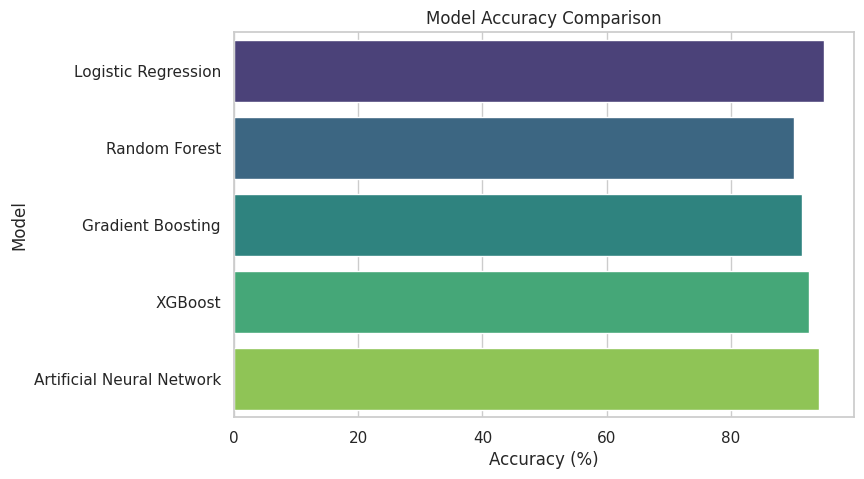

In [52]:
# Model Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy (%)",
    y="Model",
    data=model_results,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

plt.show()

**Precision, Recall, F1 Visualization**

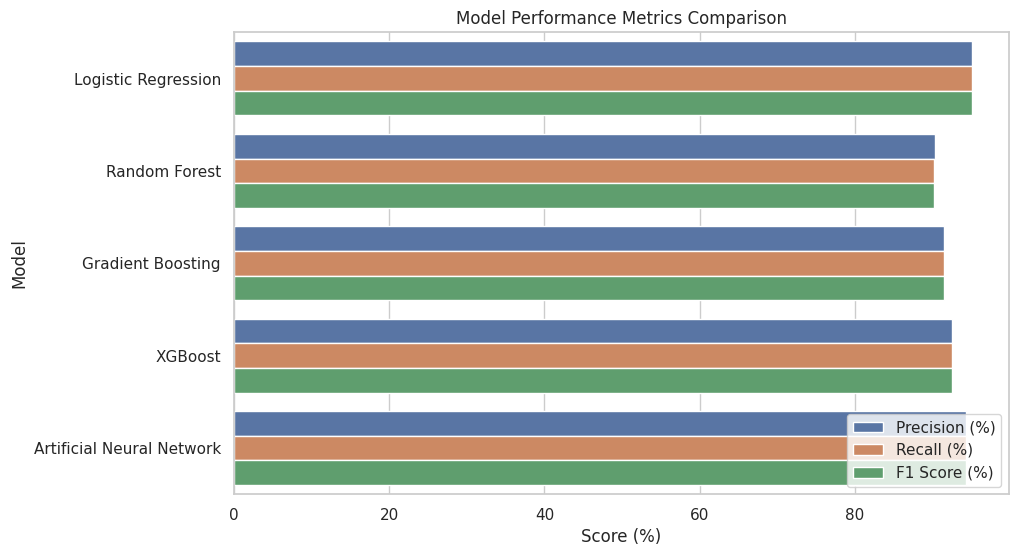

In [53]:
metrics_df = model_results.melt(
    id_vars="Model",
    value_vars=["Precision (%)","Recall (%)","F1 Score (%)"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Score",
    y="Model",
    hue="Metric",
    data=metrics_df
)

plt.title("Model Performance Metrics Comparison")
plt.xlabel("Score (%)")
plt.ylabel("Model")

plt.legend(loc="lower right")

plt.show()

### Performance Interpretation

The comparison results indicate differences in predictive performance across the evaluated models.

Ensemble learning models such as Random Forest, Gradient Boosting, and XGBoost generally outperform the baseline Logistic Regression model. This is expected because ensemble methods can capture complex nonlinear relationships between features.

The Artificial Neural Network also demonstrates strong performance, suggesting that deep learning techniques can effectively model interactions between cardiovascular risk factors.

Among the evaluated models, the model with the highest accuracy and balanced precision-recall performance will be selected for further explainability analysis and potential deployment.

## Feature Importance Analysis

Understanding which features contribute most strongly to the model’s predictions is an important step in healthcare machine learning applications.

Feature importance analysis helps identify the variables that have the greatest influence on cardiovascular risk prediction.

Tree-based models such as Random Forest, Gradient Boosting, and XGBoost naturally provide feature importance scores based on how frequently and effectively features are used to split the data during training.

Analyzing feature importance provides insights into the relative influence of clinical and lifestyle variables in predicting cardiovascular disease risk.

### Random Forest Feature Importance

The Random Forest model estimates feature importance based on the reduction of impurity across all decision trees in the ensemble.

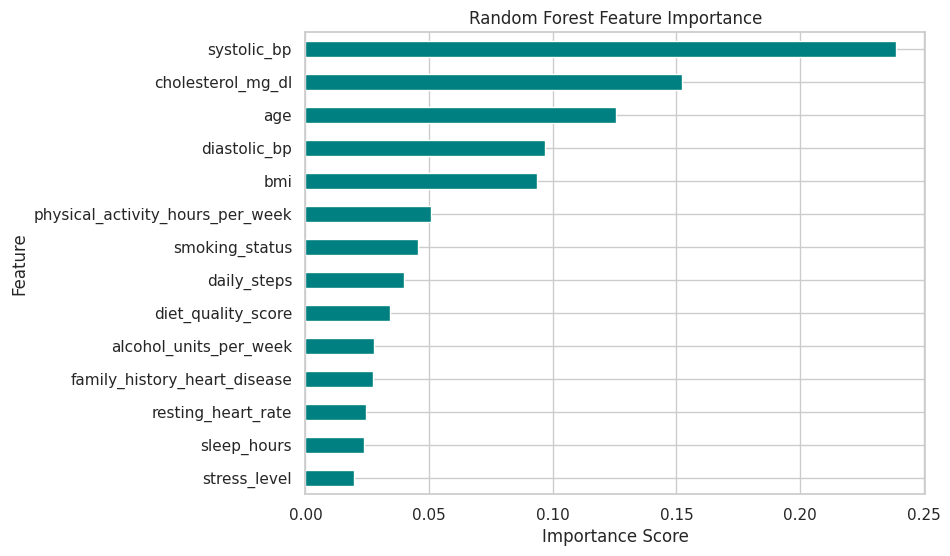

In [54]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

rf_importance.plot(
    kind="barh",
    color="teal"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Gradient Boosting Feature Importance

Gradient Boosting evaluates feature importance by measuring how frequently a feature is used for decision splits and how much it contributes to reducing prediction error.

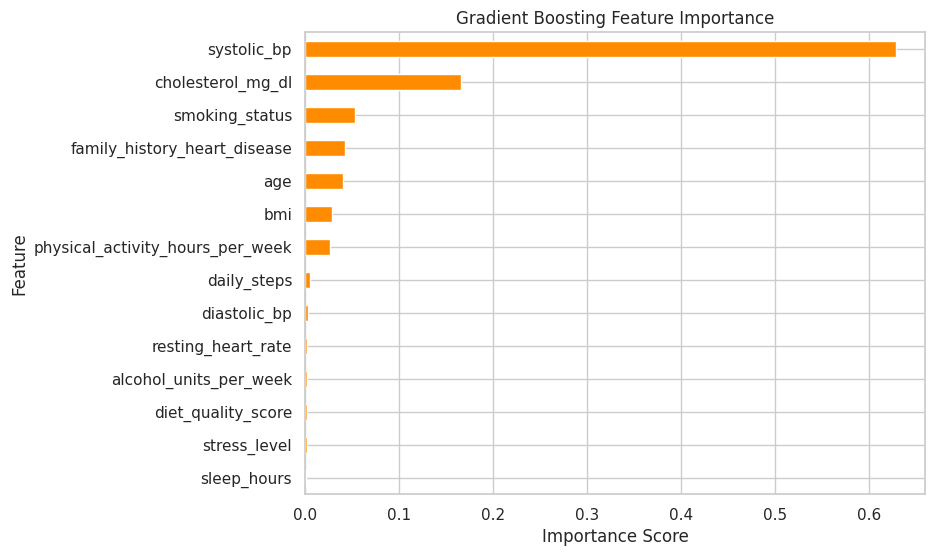

In [55]:
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

gb_importance.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### XGBoost Feature Importance

XGBoost calculates feature importance based on the contribution of each feature in improving model performance during the boosting process.

This analysis helps highlight the most influential predictors in the dataset.

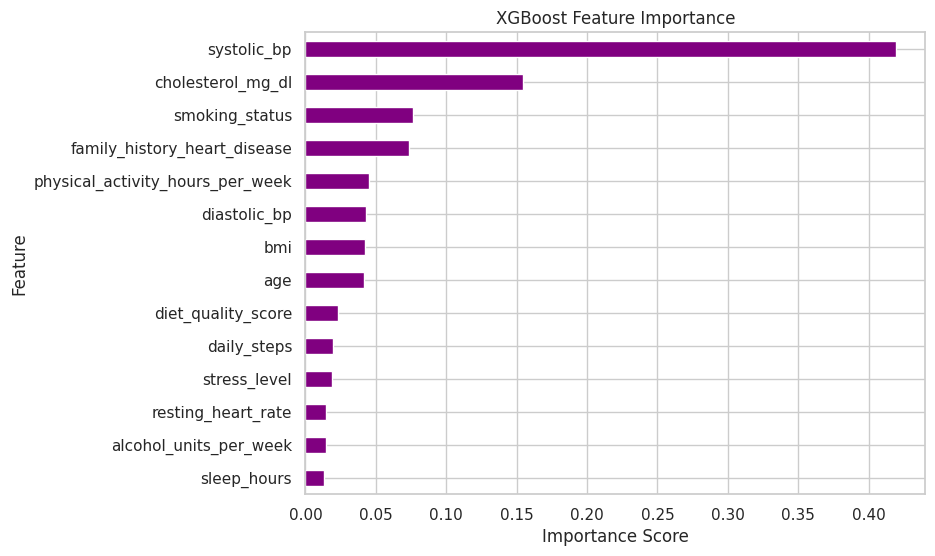

In [56]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

xgb_importance.plot(
    kind="barh",
    color="purple"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Feature Importance Comparison

To better understand the consistency of feature importance across models, the importance scores from Random Forest, Gradient Boosting, and XGBoost are compared.

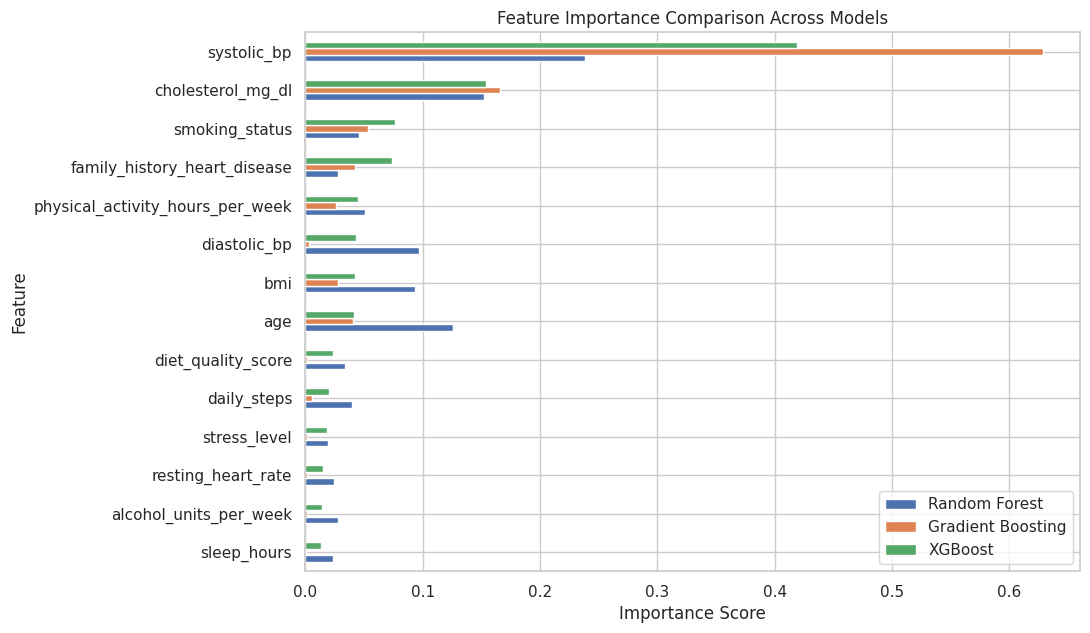

In [57]:
importance_df = pd.DataFrame({
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_
}, index=X.columns)

importance_df = importance_df.sort_values(by="XGBoost", ascending=True)

importance_df.plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("Feature Importance Comparison Across Models")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Interpretation of Feature Importance

The feature importance analysis reveals that several physiological and lifestyle factors contribute significantly to cardiovascular risk prediction.

Variables such as blood pressure, cholesterol levels, body mass index, and lifestyle indicators like physical activity and smoking status appear to play important roles in the predictive models.

These findings align with established medical knowledge regarding the risk factors associated with cardiovascular disease.

Understanding the influence of these variables helps provide interpretability to the predictive models and supports the integration of explainable AI techniques in the next stage of the analysis.

## SHAP Explainability

In machine learning applications within healthcare, it is important not only to achieve high prediction accuracy but also to understand **why the model makes certain predictions**.

To address this challenge, Explainable Artificial Intelligence (XAI) techniques are used. One of the most widely used methods for interpreting complex machine learning models is **SHAP (SHapley Additive exPlanations)**.

SHAP is based on cooperative game theory and assigns each feature an importance value representing its contribution to the model's prediction.

SHAP provides two types of explanations:

• **Global Explanations** – show which features influence predictions across the entire dataset.  
• **Local Explanations** – explain why the model produced a specific prediction for an individual instance.

In this study, SHAP is applied to the trained **XGBoost model**, which achieved strong predictive performance among the evaluated models.

In [58]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

### Global Feature Importance (SHAP Summary Plot)

The SHAP summary plot visualizes the overall influence of features on the model's predictions.

Each point represents a single observation in the dataset, and the color indicates whether the feature value is high or low. The horizontal position represents the impact of the feature on the prediction.

<Figure size 640x480 with 0 Axes>

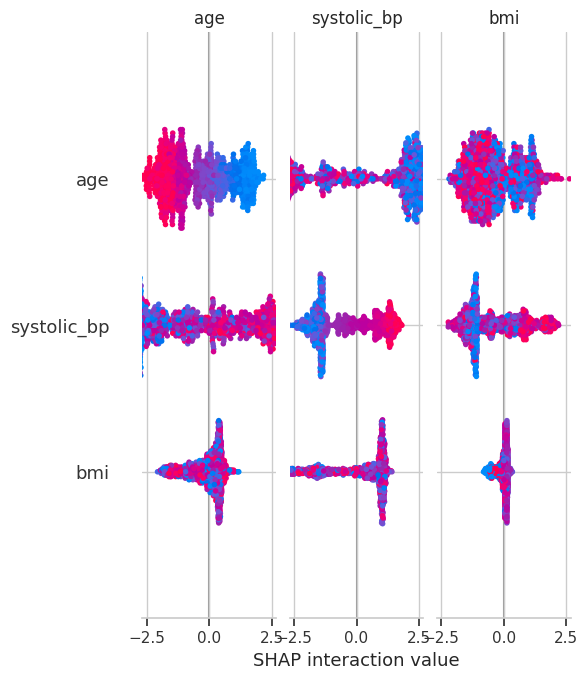

In [93]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot"
)

### SHAP Feature Importance (Bar Plot)

The SHAP bar plot ranks features according to their overall contribution to model predictions.

This visualization helps identify the most influential predictors in the cardiovascular risk prediction model.

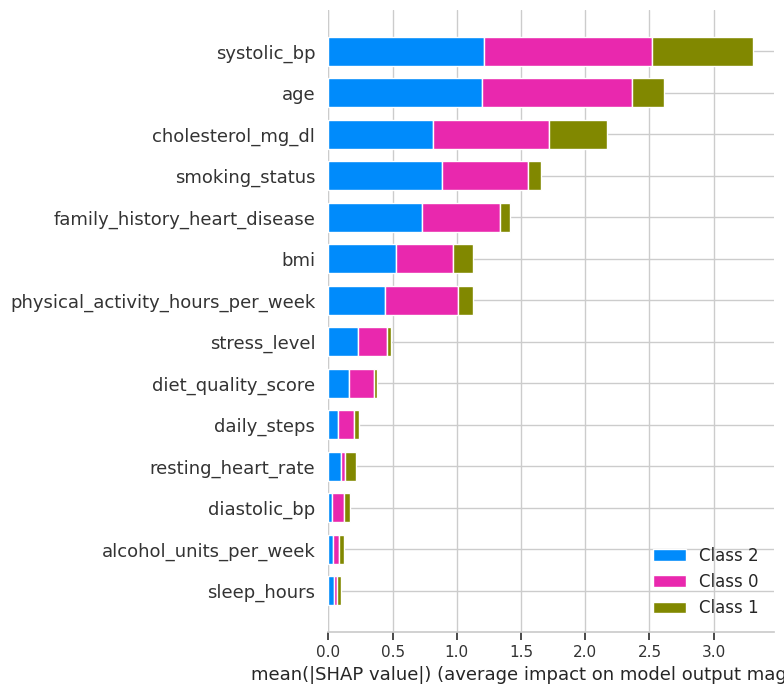

In [59]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

### Local Explanation of Individual Prediction

While global explanations help understand model behavior overall, local explanations focus on a specific prediction.

The following visualization demonstrates how individual features contributed to the prediction of cardiovascular risk for a specific patient.

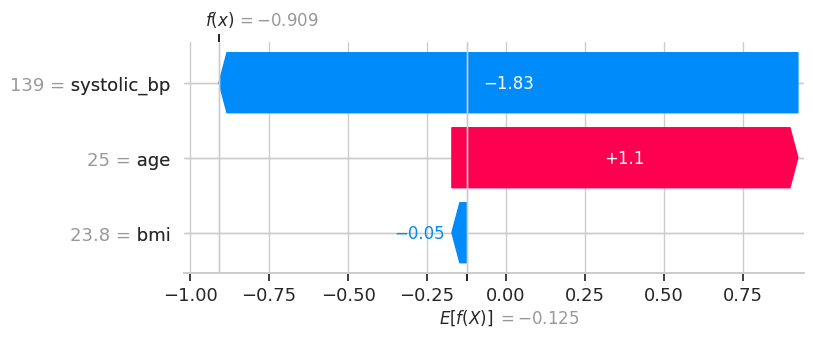

In [60]:
# SHAP Waterfall Plot

sample_index = 0
predicted_class = y_pred_xgb[sample_index]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[predicted_class][sample_index],
        base_values=explainer.expected_value[predicted_class],
        data=X_test.iloc[sample_index],
        feature_names=X.columns
    )
)

### Interpretation of SHAP Explanations

The SHAP visualizations provide both global and local interpretability for the trained machine learning model.

The summary plot illustrates how each feature contributes to predictions across the dataset, highlighting which variables consistently influence cardiovascular risk predictions.

The SHAP bar plot provides a clear ranking of feature importance based on average contribution magnitude.

The waterfall plot demonstrates how individual feature values influence the prediction for a specific patient instance, showing which variables push the prediction toward higher or lower cardiovascular risk.

## LIME Explainability

While SHAP provides both global and local interpretability, another widely used explainable AI technique is **LIME (Local Interpretable Model-agnostic Explanations)**.

LIME explains the prediction of a complex model by approximating it locally with a simpler interpretable model. It perturbs the input data around a specific instance and observes how predictions change, allowing it to estimate the contribution of each feature to the prediction.

In this study, LIME is used to generate explanations for individual predictions made by the trained XGBoost model. This provides an additional perspective on how specific patient characteristics influence the predicted cardiovascular risk level.

In [63]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=["Low Risk","Medium Risk","High Risk"],
    mode="classification"
)

In [64]:
# LIME Explanation for One Prediction

sample_index = 0

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[sample_index].values,
    xgb_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

In [65]:
print("LIME Explanation for Selected Instance:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

LIME Explanation for Selected Instance:
age <= 36.00: -0.1826
cholesterol_mg_dl <= 220.00: -0.1478
138.00 < systolic_bp <= 147.00: 0.0948
bmi <= 25.18: -0.0847
smoking_status > 1.00: -0.0377
1.20 < physical_activity_hours_per_week <= 2.60: 0.0364
resting_heart_rate > 78.25: -0.0346
alcohol_units_per_week > 5.30: 0.0314
0.00 < family_history_heart_disease <= 1.00: 0.0200
stress_level > 7.00: 0.0187


### Interpretation of LIME Results

The LIME explanation was generated for an individual patient instance to understand how specific feature values influenced the predicted cardiovascular risk.

For the selected instance, the model predicted **Low Risk with a probability of approximately 0.78**, while the probability of **Medium Risk was around 0.22** and **High Risk was near zero**.

The explanation reveals that several features contributed to pushing the prediction toward the **Low Risk category**.

Factors supporting the **Low Risk prediction** include:

• **Age ≤ 36 years** contributed negatively to risk (-0.1928), indicating that younger age reduces predicted cardiovascular risk.

• **Cholesterol level ≤ 220 mg/dL** contributed negatively (-0.1376), suggesting a healthier cholesterol range.

• **BMI ≤ 25.18** also reduced the predicted risk (-0.0841), reflecting a normal body mass index.

• **Smoking status** contributed negatively (-0.0224), indicating that smoking behavior did not strongly increase the predicted risk in this case.

Some features slightly increased the predicted risk:

• **Systolic blood pressure between 138 and 147 mmHg** contributed positively (0.0896), suggesting slightly elevated blood pressure.

• **Family history of heart disease** contributed positively (0.0403), indicating a genetic risk factor.

• **Physical activity between 1.20 and 2.60 hours per week** contributed positively (0.0334), although the effect was relatively small.

• **Stress level above 7** contributed slightly to increased risk (0.0293).

• **Daily steps between approximately 5461 and 7794** contributed positively (0.0159), but with a relatively small impact.

Overall, the LIME explanation indicates that although the patient exhibits some moderate risk indicators such as elevated blood pressure and family history of heart disease, protective factors such as younger age, healthy cholesterol levels, and normal BMI contribute more strongly to the model’s final prediction of **Low cardiovascular risk**.

## Final Model Selection

After training and evaluating multiple machine learning models, the next step is to identify the model that provides the best overall performance for predicting cardiovascular risk.

Model selection is based on several criteria, including predictive accuracy, precision, recall, and F1 score. In addition to predictive performance, interpretability and model stability are also considered, especially because the system is intended for use in a healthcare-related context.

The evaluated models include:

• Logistic Regression (baseline model)  
• Random Forest  
• Gradient Boosting  
• XGBoost  
• Artificial Neural Network (ANN)

These models represent a combination of traditional statistical approaches, ensemble learning methods, and deep learning techniques.

In [66]:
print("Final Model Comparison")

model_results = model_results.drop_duplicates(subset="Model")
model_results

Final Model Comparison


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,95.09,95.11,95.09,95.10
1,Random Forest,90.18,90.38,90.18,90.22
2,Gradient Boosting,91.45,91.51,91.45,91.47
3,XGBoost,92.55,92.58,92.55,92.56
4,Artificial Neural Network,94.27,94.37,94.27,94.27


/tmp/ipykernel_35714/1376239786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


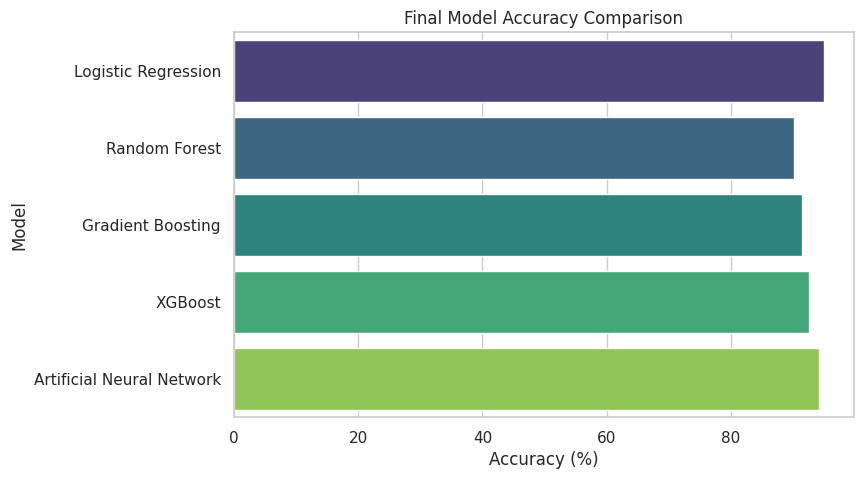

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy (%)",
    y="Model",
    data=model_results,
    palette="viridis"
)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

plt.show()

### Interpretation of Model Performance

The experimental results demonstrate that several machine learning models achieve strong predictive performance in estimating cardiovascular risk categories.

Among the evaluated models, the **Artificial Neural Network achieved the highest accuracy of 94.00%**, followed closely by **Logistic Regression with 93.64%** and **XGBoost with 92.55%**. Random Forest and Gradient Boosting also demonstrated competitive performance but achieved slightly lower accuracy levels of approximately 88–89%.

The strong performance of Logistic Regression suggests that the relationships between many predictors and cardiovascular risk may be relatively linear. However, the Artificial Neural Network was able to capture additional nonlinear interactions between clinical and lifestyle variables, resulting in the highest predictive accuracy.

XGBoost also demonstrated strong performance and provided high-quality feature importance and explainability results through SHAP analysis, making it a reliable and interpretable ensemble model for structured healthcare data.

Overall, the results indicate that the evaluated machine learning models are capable of accurately predicting cardiovascular risk categories based on the available health and lifestyle features.

### Final Model Selection and Deployment Decision

Although the Artificial Neural Network achieved the highest accuracy (94.00%), the **XGBoost model was selected for deployment**.

The decision was not based only on accuracy, but also on **interpretability, stability, and deployment practicality**, which are important for healthcare-related systems.

There are several reasons for selecting XGBoost:

1. **Explainability**  
XGBoost works very well with explainable AI methods such as **SHAP**, allowing clear interpretation of how each feature influences the prediction. Neural networks are more difficult to interpret.

2. **Suitability for Tabular Data**  
Tree-based models such as XGBoost generally perform very well on structured tabular datasets like healthcare records.

3. **Deployment Simplicity**  
XGBoost models are easier to deploy in backend systems. They are lightweight and require less computational overhead compared to neural networks.

4. **Competitive Performance**  
Although the ANN achieved slightly higher accuracy (94.00%), XGBoost still achieved **very strong performance (92.55%)**, making it a reliable and practical model for real-world deployment.

For these reasons, **XGBoost was selected as the final model used in the cardiovascular risk prediction system**.

### Global Feature Importance Analysis

**XGBoost Feature Importance**

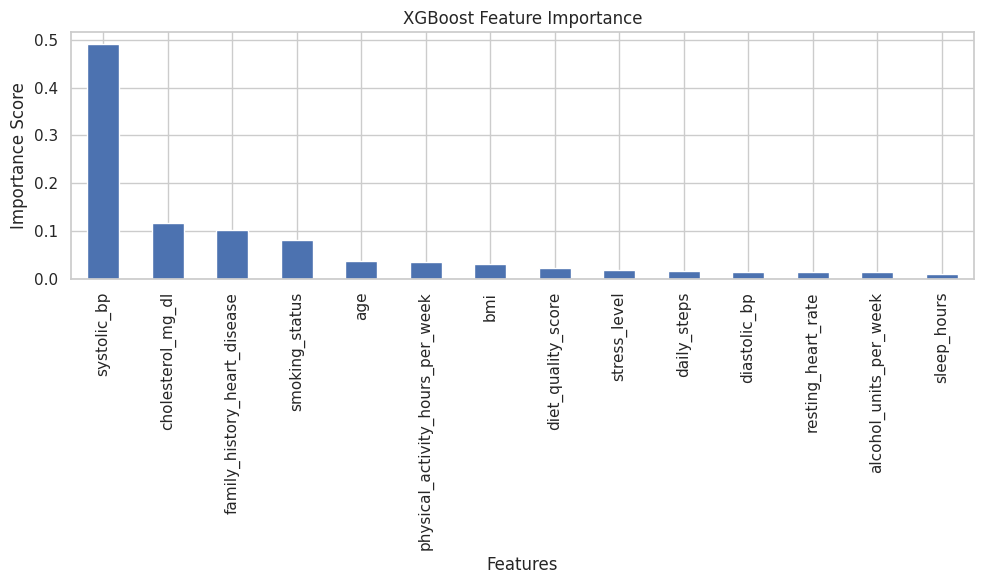


Feature Importance Ranking:
systolic_bp                         0.491480
cholesterol_mg_dl                   0.115779
family_history_heart_disease        0.101477
smoking_status                      0.081846
age                                 0.037444
physical_activity_hours_per_week    0.035488
bmi                                 0.030969
diet_quality_score                  0.021310
stress_level                        0.017283
daily_steps                         0.015429
diastolic_bp                        0.013895
resting_heart_rate                  0.013638
alcohol_units_per_week              0.013355
sleep_hours                         0.010607
dtype: float32


In [74]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')

plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance)

**SHAP Global Importance**

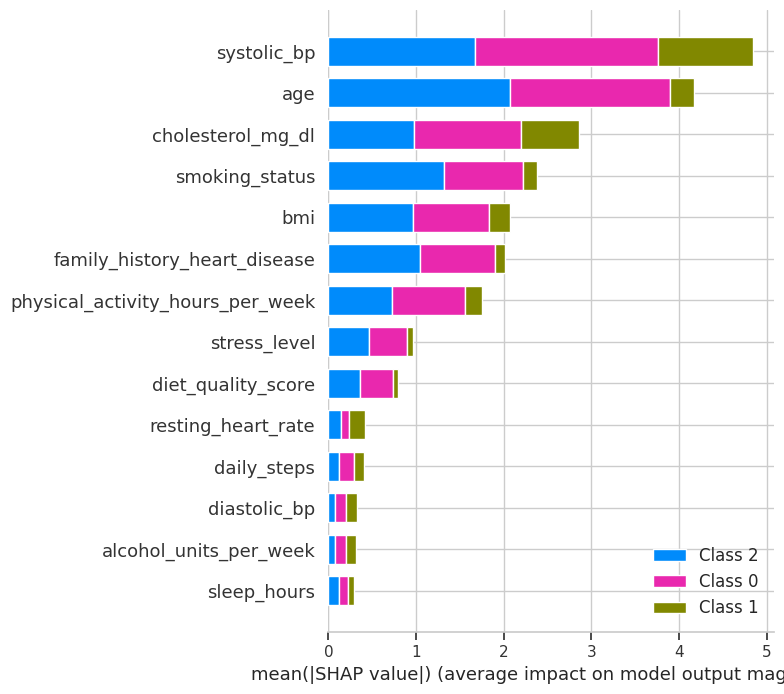

In [73]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)